# OCR GAN Notebook for Kaggle

This notebook is written for Kaggle GPU, not TPU. It uses a pix2pix-style conditional GAN to generate content-preserving document degradations and then evaluates OCR robustness with free local OCR models by default.

OCR attack loss is not used as a differentiable training objective for black-box APIs. Instead, the notebook trains the GAN with adversarial and reconstruction losses, then evaluates the results with local OCR engines and an optional free OCR.space API call.

Primary OCR options in this notebook:
- TrOCR
- EasyOCR
- pytesseract, if the Tesseract binary is available in the environment
- Optional OCR.space free-tier API through an environment variable

SynthText labels are loaded directly from `gt.mat` when available, so the notebook can compute real OCR accuracy metrics instead of only qualitative outputs.

Kaggle is the better default for this project because it gives you a normal GPU workflow for GANs. TPU is not a good fit for this training setup.

In [ ]:
import os
import sys
import json
import math
import random
import shutil
import subprocess
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageFilter, ImageOps, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid


def install_if_missing(package_name: str) -> None:
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


for package_name in [
    "python-dotenv",
    "easyocr",
    "transformers",
    "sentencepiece",
    "scipy",
    "opencv-python-headless",
    "requests",
    "tqdm",
]:
    try:
        __import__(package_name.replace("-", "_"))
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package_name], check=False)


try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None

try:
    import cv2
except Exception:
    cv2 = None

try:
    import requests
except Exception:
    requests = None

try:
    import easyocr
except Exception:
    easyocr = None

try:
    import pytesseract
except Exception:
    pytesseract = None

try:
    from scipy.io import loadmat
except Exception:
    loadmat = None

try:
    from transformers import TrOCRProcessor, VisionEncoderDecoderModel
except Exception:
    TrOCRProcessor = None
    VisionEncoderDecoderModel = None

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable


if load_dotenv is not None:
    load_dotenv(".env")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Torch version: {torch.__version__}")


RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.benchmark = True


@dataclass
class ProjectConfig:
    kaggle_input_roots: List[str] = field(default_factory=lambda: ["/kaggle/input/synthtext/SynthText"])
    work_root: Path = Path("/kaggle/working")
    output_root: Path = Path("/kaggle/working/ocr_gan_outputs")
    checkpoints_root: Path = Path("/kaggle/working/ocr_gan_checkpoints")
    image_size: int = 256
    batch_size: int = 8
    num_workers: int = 2
    learning_rate: float = 2e-4
    beta1: float = 0.5
    lambda_l1: float = 100.0
    lambda_identity: float = 10.0
    lambda_edge: float = 5.0
    lambda_perceptual: float = 1.0
    epochs: int = 10
    max_train_samples: Optional[int] = 5000
    max_eval_samples: Optional[int] = 200
    gradcam_samples: int = 3
    trocr_model_name: str = "microsoft/trocr-base-printed"
    ocrspace_api_key: str = ""


config = ProjectConfig()
config.output_root.mkdir(parents=True, exist_ok=True)
config.checkpoints_root.mkdir(parents=True, exist_ok=True)


print(json.dumps({
    "image_size": config.image_size,
    "batch_size": config.batch_size,
    "epochs": config.epochs,
    "max_train_samples": config.max_train_samples,
    "max_eval_samples": config.max_eval_samples,
    "trocr_available": TrOCRProcessor is not None and VisionEncoderDecoderModel is not None,
    "ocrspace_api_key_present": bool(config.ocrspace_api_key),
}, indent=2))

Using device: cuda
Torch version: 2.10.0+cu128
{
  "image_size": 256,
  "batch_size": 8,
  "epochs": 10,
  "max_train_samples": 5000,
  "max_eval_samples": 200,
  "trocr_available": true,
  "ocrspace_api_key_present": true
}


## Kaggle Notebook Setup and Dataset Loading

Use Kaggle GPU for this project. Attach your datasets in Kaggle and point the notebook at the `/kaggle/input/...` directories.

If you already have a clean text-image dataset with transcripts, the notebook can build a manifest from a CSV or scan a folder recursively. If you only have image folders, the notebook can still run, but OCR evaluation will be text-less until you supply labels.

In [4]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}


def list_kaggle_roots() -> List[Path]:
    root = Path("/kaggle/input")
    if not root.exists():
        return []
    return [path for path in root.iterdir() if path.is_dir()]


print("Available Kaggle input roots:")
for root in list_kaggle_roots():
    print(" -", root)


@dataclass
class SampleRecord:
    image_path: Path
    text: str = ""


def find_csv_manifest(root: Path) -> Optional[Path]:
    for candidate in root.rglob("*.csv"):
        lower_name = candidate.name.lower()
        if any(token in lower_name for token in ["manifest", "labels", "annotation", "annotations", "train", "gt"]):
            return candidate
    csv_files = list(root.rglob("*.csv"))
    return csv_files[0] if csv_files else None


def find_synthtext_ground_truth(root: Path) -> Optional[Path]:
    for candidate in [root / "gt.mat", root / "SynthText" / "gt.mat"]:
        if candidate.exists():
            return candidate
    matches = list(root.rglob("gt.mat"))
    return matches[0] if matches else None


def matlab_to_string(value) -> str:
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore")
    if isinstance(value, str):
        return value
    if isinstance(value, np.ndarray):
        if value.size == 0:
            return ""
        if value.dtype.kind in {"U", "S"}:
            return " ".join(str(item) for item in value.flatten().tolist())
        if value.size == 1:
            return matlab_to_string(value.item())
        return " ".join(part for part in (matlab_to_string(item) for item in value.flatten()) if part)
    return str(value)


def normalize_synthtext_transcript(value) -> str:
    raw_text = matlab_to_string(value)
    raw_text = raw_text.replace("\r", "\n")
    lines = [line.strip() for line in raw_text.split("\n") if line.strip()]
    return " ".join(lines)


def extract_synthtext_crop_box(value) -> Tuple[Optional[int], Optional[int], Optional[int], Optional[int]]:
    if value is None:
        return (None, None, None, None)

    try:
        points = np.asarray(value, dtype=np.float32)
    except Exception:
        return (None, None, None, None)

    if points.size == 0:
        return (None, None, None, None)

    try:
        flattened = points.reshape(2, -1)
    except Exception:
        return (None, None, None, None)

    x_coordinates = flattened[0]
    y_coordinates = flattened[1]
    if x_coordinates.size == 0 or y_coordinates.size == 0:
        return (None, None, None, None)

    left = int(np.floor(np.nanmin(x_coordinates)))
    top = int(np.floor(np.nanmin(y_coordinates)))
    right = int(np.ceil(np.nanmax(x_coordinates)))
    bottom = int(np.ceil(np.nanmax(y_coordinates)))
    if right <= left or bottom <= top:
        return (None, None, None, None)
    return (left, top, right, bottom)


def build_synthtext_dataframe(root: Path, max_samples: Optional[int] = None) -> Optional[pd.DataFrame]:
    gt_path = find_synthtext_ground_truth(root)
    if gt_path is None or loadmat is None:
        return None

    try:
        gt_data = loadmat(gt_path)
    except Exception as error:
        print(f"Failed to read SynthText labels from {gt_path}: {error}")
        return None

    imnames = gt_data.get("imnames")
    txt_values = gt_data.get("txt")
    word_boxes = gt_data.get("wordBB")
    if imnames is None or txt_values is None:
        return None

    image_entries = imnames.ravel()
    text_entries = txt_values.ravel()
    word_box_entries = word_boxes.ravel() if word_boxes is not None else []
    row_count = min(len(image_entries), len(text_entries))
    rows = []
    for index in range(row_count):
        relative_path = matlab_to_string(image_entries[index]).strip()
        transcript = normalize_synthtext_transcript(text_entries[index])
        if not relative_path:
            continue
        crop_left, crop_top, crop_right, crop_bottom = extract_synthtext_crop_box(word_box_entries[index]) if index < len(word_box_entries) else (None, None, None, None)
        image_path = gt_path.parent / relative_path
        rows.append({
            "image_path": str(image_path.resolve()),
            "text": transcript,
            "crop_left": crop_left,
            "crop_top": crop_top,
            "crop_right": crop_right,
            "crop_bottom": crop_bottom,
        })
        if max_samples is not None and len(rows) >= max_samples:
            break

    if not rows:
        return None

    dataframe = pd.DataFrame(rows)
    print(f"Loaded SynthText labels from: {gt_path}")
    return dataframe


def read_manifest(csv_path: Path) -> pd.DataFrame:
    dataframe = pd.read_csv(csv_path)
    columns = {column.lower(): column for column in dataframe.columns}
    image_column = None
    text_column = None
    for candidate in ["image_path", "path", "file", "filename", "img", "image"]:
        if candidate in columns:
            image_column = columns[candidate]
            break
    for candidate in ["text", "label", "transcript", "gt_text", "ground_truth"]:
        if candidate in columns:
            text_column = columns[candidate]
            break
    if image_column is None:
        raise ValueError(f"Could not find an image path column in {csv_path}")
    if text_column is None:
        dataframe["text"] = ""
        text_column = "text"
    dataframe = dataframe[[image_column, text_column]].copy()
    dataframe.columns = ["image_path", "text"]
    dataframe["image_path"] = dataframe["image_path"].astype(str)
    dataframe["text"] = dataframe["text"].astype(str)
    return dataframe


def discover_image_rows(root: Path, max_samples: Optional[int] = None) -> pd.DataFrame:
    synthtext_dataframe = build_synthtext_dataframe(root, max_samples=max_samples)
    if synthtext_dataframe is not None:
        return synthtext_dataframe

    csv_manifest = find_csv_manifest(root)
    if csv_manifest is not None:
        print(f"Using manifest: {csv_manifest}")
        dataframe = read_manifest(csv_manifest)
        dataframe["image_path"] = dataframe["image_path"].apply(lambda value: str((csv_manifest.parent / value).resolve()) if not os.path.isabs(value) else value)
        if max_samples is not None:
            dataframe = dataframe.head(max_samples)
        return dataframe

    image_paths = [path for path in root.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS]
    rows = [{"image_path": str(path), "text": ""} for path in image_paths]
    dataframe = pd.DataFrame(rows)
    if max_samples is not None:
        dataframe = dataframe.head(max_samples)
    return dataframe


configured_roots = [Path(path) for path in config.kaggle_input_roots if Path(path).exists()]
candidate_roots = configured_roots if configured_roots else list_kaggle_roots()

if candidate_roots:
    dataset_parts = []
    for root in candidate_roots:
        dataframe = discover_image_rows(root, config.max_train_samples)
        if not dataframe.empty:
            dataset_parts.append(dataframe)
    dataset_dataframe = pd.concat(dataset_parts, ignore_index=True) if dataset_parts else pd.DataFrame(columns=["image_path", "text"])
else:
    dataset_dataframe = pd.DataFrame(columns=["image_path", "text"])

print(f"Loaded {len(dataset_dataframe)} candidate images")
print(f"Rows with non-empty text labels: {int(dataset_dataframe['text'].astype(str).str.strip().ne('').sum()) if not dataset_dataframe.empty else 0}")
display(dataset_dataframe.head())


if len(dataset_dataframe) == 0:
    print("No attached dataset found yet. Upload SynthText/MJSynth or your own OCR dataset to Kaggle and rerun this cell.")

Available Kaggle input roots:
 - /kaggle/input/datasets
Loaded SynthText labels from: /kaggle/input/datasets/wassefy/synthtext/SynthText/gt.mat
Loaded 5000 candidate images
Rows with non-empty text labels: 5000


,image_path,text,crop_left,crop_top,crop_right,crop_bottom
0,/kaggle/input/datasets/wassefy/synthtext/Synth...,Lines: I lost Kevin will line...,99,5,520,270
1,/kaggle/input/datasets/wassefy/synthtext/Synth...,with Sender: BNR-RTP...,255,14,578,400
2,/kaggle/input/datasets/wassefy/synthtext/Synth...,"Fern Mutch, void his loony it's From...",83,4,574,410
3,/kaggle/input/datasets/wassefy/synthtext/Synth...,Re: reins neck War for the news ...,79,6,554,326
4,/kaggle/input/datasets/wassefy/synthtext/Synth...,Scott Sender: use between ...,14,5,548,424


## Preprocess Images for OCR and Training

The GAN training path uses synthetic document degradations created on the fly from clean inputs.

The OCR evaluation path uses preprocessing helpers such as grayscale conversion, denoising, thresholding, and resizing before sending images to the OCR engines.

In [5]:
def pil_to_rgb_array(image: Image.Image) -> np.ndarray:
    return np.array(image.convert("RGB"))


def resize_to_square(image: Image.Image, size: int = 256) -> Image.Image:
    return ImageOps.fit(image.convert("RGB"), (size, size), method=Image.Resampling.LANCZOS)


def add_document_degradation(
    image: Image.Image,
    rng: Optional[random.Random] = None,
    np_rng: Optional[np.random.Generator] = None,
) -> Image.Image:
    rng = rng or random
    np_rng = np_rng or np.random.default_rng()
    working_image = image.convert("RGB")
    width, height = working_image.size

    if rng.random() < 0.7:
        contrast = ImageEnhance.Contrast(working_image)
        working_image = contrast.enhance(rng.uniform(0.7, 1.4))

    if rng.random() < 0.5:
        sharpness = ImageEnhance.Sharpness(working_image)
        working_image = sharpness.enhance(rng.uniform(0.6, 1.6))

    if rng.random() < 0.5:
        working_image = working_image.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.2, 1.4)))

    canvas = working_image.copy()
    overlay = Image.new("RGBA", (width, height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    if rng.random() < 0.8:
        top_alpha = rng.randint(10, 45)
        bottom_alpha = rng.randint(0, 35)
        for y in range(height):
            alpha = int(top_alpha + (bottom_alpha - top_alpha) * (y / max(height - 1, 1)))
            draw.line((0, y, width, y), fill=(0, 0, 0, alpha))

    if rng.random() < 0.6:
        shadow_x0 = rng.randint(0, max(0, width // 3))
        shadow_y0 = rng.randint(0, max(0, height // 3))
        shadow_x1 = min(width, shadow_x0 + rng.randint(width // 4, width // 2))
        shadow_y1 = min(height, shadow_y0 + rng.randint(height // 5, height // 2))
        draw.rectangle((shadow_x0, shadow_y0, shadow_x1, shadow_y1), fill=(0, 0, 0, rng.randint(15, 50)))

    if rng.random() < 0.4:
        fold_x = rng.randint(0, width - 1)
        draw.line((fold_x, 0, fold_x + rng.randint(-12, 12), height), fill=(255, 255, 255, rng.randint(20, 60)), width=rng.randint(1, 3))

    blended = Image.alpha_composite(canvas.convert("RGBA"), overlay).convert("RGB")

    if rng.random() < 0.5:
        noisy = np.array(blended).astype(np.float32)
        noise = np_rng.normal(0, rng.uniform(3.0, 18.0), noisy.shape).astype(np.float32)
        noisy = np.clip(noisy + noise, 0, 255).astype(np.uint8)
        blended = Image.fromarray(noisy)

    return blended


preprocess_for_ocr = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda image: resize_to_square(image, config.image_size)),
    transforms.Grayscale(num_output_channels=1),
])


train_image_transform = transforms.Compose([
    transforms.Lambda(lambda image: resize_to_square(image, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


def tensor_to_pil(image_tensor: torch.Tensor) -> Image.Image:
    if image_tensor.dim() == 4:
        image_tensor = image_tensor[0]
    image_tensor = image_tensor.detach().cpu().clamp(-1, 1)
    image_tensor = (image_tensor + 1.0) / 2.0
    image_array = (image_tensor.permute(1, 2, 0).numpy() * 255.0).astype(np.uint8)
    return Image.fromarray(image_array)


def normalize_for_display(image_tensor: torch.Tensor) -> torch.Tensor:
    return image_tensor.clamp(-1, 1)


print("Preprocessing helpers are ready.")

Preprocessing helpers are ready.


## Run OCR with Free Local Engines and Optional Free API

The notebook evaluates OCR with free local engines first. That keeps the workflow runnable even if you do not want to use any online API.

The default OCR stack is TrOCR, EasyOCR, and Tesseract. OCR.space remains optional and is used only when you provide a key in `.env`.

In [6]:
class TrOCRRunner:
    def __init__(self, model_name: str):
        self.processor = None
        self.model = None
        self.init_error = None

        if TrOCRProcessor is None or VisionEncoderDecoderModel is None:
            self.init_error = RuntimeError("transformers TrOCR is not installed")
            return

        try:
            self.processor = TrOCRProcessor.from_pretrained(model_name)
            self.model = VisionEncoderDecoderModel.from_pretrained(model_name).to(DEVICE)
            self.model.eval()
        except Exception as error:
            self.init_error = error
            print(f"TrOCR initialization failed: {error}")

    @torch.no_grad()
    def __call__(self, image: Image.Image) -> str:
        if self.processor is None or self.model is None:
            return ""
        pixel_values = self.processor(images=image.convert("RGB"), return_tensors="pt").pixel_values.to(DEVICE)
        generated_ids = self.model.generate(pixel_values)
        return self.processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()


class EasyOCRRunner:
    def __init__(self, languages: Sequence[str] = ("en",)):
        self.reader = None
        if easyocr is not None:
            self.reader = easyocr.Reader(list(languages), gpu=torch.cuda.is_available())

    def __call__(self, image: Image.Image) -> str:
        if self.reader is None:
            return ""
        image_array = np.array(image.convert("RGB"))
        result = self.reader.readtext(image_array, detail=0, paragraph=True)
        return " ".join(result).strip()


class TesseractRunner:
    def __call__(self, image: Image.Image) -> str:
        if pytesseract is None:
            return ""
        try:
            return pytesseract.image_to_string(image)
        except Exception:
            return ""


class OCRSpaceRunner:
    def __init__(self, api_key: str = ""):
        self.api_key = api_key.strip()

    def __call__(self, image: Image.Image) -> str:
        if not self.api_key or requests is None:
            return ""
        import io

        buffer = io.BytesIO()
        image.save(buffer, format="PNG")
        response = requests.post(
            "https://api.ocr.space/parse/image",
            files={"filename": ("image.png", buffer.getvalue(), "image/png")},
            data={"apikey": self.api_key, "language": "eng", "isTable": "false", "OCREngine": "2"},
            timeout=60,
        )
        try:
            payload = response.json()
            parsed_results = payload.get("ParsedResults", [])
            if parsed_results:
                return parsed_results[0].get("ParsedText", "").strip()
        except Exception:
            pass
        return ""


trocr_ocr = TrOCRRunner(config.trocr_model_name)
easy_ocr = EasyOCRRunner()
tesseract_ocr = TesseractRunner()
ocr_space_ocr = OCRSpaceRunner(config.ocrspace_api_key)


ocr_engines = {
    "trocr": trocr_ocr,
    "easyocr": easy_ocr,
    "tesseract": tesseract_ocr,
    "ocrspace": ocr_space_ocr,
}


print({
    "trocr_enabled": trocr_ocr.model is not None,
    "easyocr_enabled": easy_ocr.reader is not None,
    "tesseract_enabled": pytesseract is not None,
    "ocrspace_enabled": bool(config.ocrspace_api_key),
})


def preprocess_for_local_ocr(image: Image.Image) -> Image.Image:
    processed = image.convert("L")
    processed = ImageOps.autocontrast(processed)
    processed = processed.filter(ImageFilter.MedianFilter(size=3))
    processed = processed.resize((max(1, processed.width * 2), max(1, processed.height * 2)))
    return processed.convert("RGB")


def run_ocr_engine(engine_name: str, image: Image.Image) -> str:
    engine = ocr_engines.get(engine_name)
    if engine is None:
        return ""
    prepared_image = preprocess_for_local_ocr(image) if engine_name in {"trocr", "easyocr", "tesseract"} else image
    try:
        return engine(prepared_image)
    except Exception as error:
        print(f"OCR engine {engine_name} failed: {error}")
        return ""


print("OCR helpers are ready.")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

{'trocr_enabled': True, 'easyocr_enabled': True, 'tesseract_enabled': True, 'ocrspace_enabled': True}
OCR helpers are ready.


## Pix2Pix-Style Conditional GAN

The generator maps a clean text image to a realistic degraded version. The discriminator judges whether the paired clean/degraded image looks real.

This notebook does not rely on a differentiable OCR API. Black-box OCR is used for evaluation only, while training uses adversarial, reconstruction, edge, and perceptual-style losses.

In [7]:
class PairedDocumentDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        image_size: int = 256,
        training: bool = True,
        deterministic_degradation: bool = False,
        base_seed: int = RANDOM_SEED,
    ):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.image_size = image_size
        self.training = training
        self.deterministic_degradation = deterministic_degradation
        self.base_seed = base_seed
        self.to_tensor = transforms.Compose([
            transforms.Lambda(lambda image: resize_to_square(image, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

    def __len__(self) -> int:
        return len(self.dataframe)

    def _crop_image(self, image: Image.Image, row: pd.Series) -> Image.Image:
        crop_columns = ["crop_left", "crop_top", "crop_right", "crop_bottom"]
        if not all(column in row.index for column in crop_columns):
            return image

        crop_values = [row.get(column) for column in crop_columns]
        if any(pd.isna(value) for value in crop_values):
            return image

        left, top, right, bottom = [int(float(value)) for value in crop_values]
        if right <= left or bottom <= top:
            return image

        padding_x = max(12, int((right - left) * 0.08))
        padding_y = max(12, int((bottom - top) * 0.08))
        left = max(0, left - padding_x)
        top = max(0, top - padding_y)
        right = min(image.width, right + padding_x)
        bottom = min(image.height, bottom + padding_y)
        if right <= left or bottom <= top:
            return image
        return image.crop((left, top, right, bottom))

    def _build_degraded_image(self, image: Image.Image, index: int) -> Image.Image:
        if not self.training:
            return image
        if not self.deterministic_degradation:
            return add_document_degradation(image)

        rng = random.Random(self.base_seed + int(index))
        np_rng = np.random.default_rng(self.base_seed + int(index))
        return add_document_degradation(image, rng=rng, np_rng=np_rng)

    def __getitem__(self, index: int) -> Dict[str, object]:
        row = self.dataframe.iloc[index]
        image_path = Path(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        image = self._crop_image(image, row)
        degraded_image = self._build_degraded_image(image, index)
        clean_tensor = self.to_tensor(image)
        degraded_tensor = self.to_tensor(degraded_image)
        return {
            "clean": clean_tensor,
            "degraded": degraded_tensor,
            "text": str(row.get("text", "")),
            "path": str(image_path),
        }


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, normalize: bool = True):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=not normalize)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.block(inputs)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.block(inputs)


class UNetGenerator(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 3, base_channels: int = 64):
        super().__init__()
        self.down1 = DownBlock(in_channels, base_channels, normalize=False)
        self.down2 = DownBlock(base_channels, base_channels * 2)
        self.down3 = DownBlock(base_channels * 2, base_channels * 4)
        self.down4 = DownBlock(base_channels * 4, base_channels * 8)
        self.down5 = DownBlock(base_channels * 8, base_channels * 8)
        self.down6 = DownBlock(base_channels * 8, base_channels * 8)
        self.down7 = DownBlock(base_channels * 8, base_channels * 8)
        self.down8 = DownBlock(base_channels * 8, base_channels * 8, normalize=False)

        self.up1 = UpBlock(base_channels * 8, base_channels * 8, dropout=0.5)
        self.up2 = UpBlock(base_channels * 16, base_channels * 8, dropout=0.5)
        self.up3 = UpBlock(base_channels * 16, base_channels * 8, dropout=0.5)
        self.up4 = UpBlock(base_channels * 16, base_channels * 8)
        self.up5 = UpBlock(base_channels * 16, base_channels * 4)
        self.up6 = UpBlock(base_channels * 8, base_channels * 2)
        self.up7 = UpBlock(base_channels * 4, base_channels)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(base_channels * 2, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        d1 = self.down1(inputs)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        bottleneck = self.down8(d7)

        u1 = self.up1(bottleneck)
        u2 = self.up2(torch.cat([u1, d7], dim=1))
        u3 = self.up3(torch.cat([u2, d6], dim=1))
        u4 = self.up4(torch.cat([u3, d5], dim=1))
        u5 = self.up5(torch.cat([u4, d4], dim=1))
        u6 = self.up6(torch.cat([u5, d3], dim=1))
        u7 = self.up7(torch.cat([u6, d2], dim=1))
        return self.final(torch.cat([u7, d1], dim=1))


class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels: int = 3, base_channels: int = 64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels * 4, base_channels * 8, kernel_size=4, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels * 8, 1, kernel_size=4, stride=1, padding=1),
        )

    def forward(self, clean_image: torch.Tensor, target_image: torch.Tensor) -> torch.Tensor:
        return self.model(torch.cat([clean_image, target_image], dim=1))


class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        kernel_x = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=torch.float32)
        kernel_y = torch.tensor([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=torch.float32)
        sobel_kernel = torch.stack([kernel_x, kernel_y]).unsqueeze(1)
        self.register_buffer("sobel_kernel", sobel_kernel)

    def forward(self, prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        prediction_gray = prediction.mean(dim=1, keepdim=True)
        target_gray = target.mean(dim=1, keepdim=True)
        prediction_edges = F.conv2d(prediction_gray, self.sobel_kernel, padding=1)
        target_edges = F.conv2d(target_gray, self.sobel_kernel, padding=1)
        return F.l1_loss(prediction_edges, target_edges)



def perceptual_loss_factory() -> nn.Module:
    try:
        from torchvision.models import VGG16_Weights, vgg16
        vgg_features = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval().to(DEVICE)
        for parameter in vgg_features.parameters():
            parameter.requires_grad = False
    except Exception:
        vgg_features = None

    class VGGPerceptualLoss(nn.Module):
        def __init__(self, feature_extractor: Optional[nn.Module]):
            super().__init__()
            self.feature_extractor = feature_extractor
            self.normalization = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        def forward(self, prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
            if self.feature_extractor is None:
                return torch.tensor(0.0, device=prediction.device)
            prediction_rescaled = (prediction + 1.0) / 2.0
            target_rescaled = (target + 1.0) / 2.0
            prediction_input = self.normalization(prediction_rescaled)
            target_input = self.normalization(target_rescaled)
            prediction_features = self.feature_extractor(prediction_input)
            target_features = self.feature_extractor(target_input)
            return F.l1_loss(prediction_features, target_features)

    return VGGPerceptualLoss(vgg_features)


G = UNetGenerator().to(DEVICE)
D = PatchDiscriminator().to(DEVICE)
edge_loss = EdgeLoss().to(DEVICE)
perceptual_loss = perceptual_loss_factory().to(DEVICE)

adversarial_criterion = nn.BCEWithLogitsLoss()
reconstruction_criterion = nn.L1Loss()


def discriminator_loss(real_prediction: torch.Tensor, fake_prediction: torch.Tensor) -> torch.Tensor:
    real_targets = torch.ones_like(real_prediction)
    fake_targets = torch.zeros_like(fake_prediction)
    real_loss = adversarial_criterion(real_prediction, real_targets)
    fake_loss = adversarial_criterion(fake_prediction, fake_targets)
    return 0.5 * (real_loss + fake_loss)



def generator_loss(fake_prediction: torch.Tensor, fake_image: torch.Tensor, target_image: torch.Tensor, identity_image: torch.Tensor) -> Dict[str, torch.Tensor]:
    adversarial_loss = adversarial_criterion(fake_prediction, torch.ones_like(fake_prediction))
    l1_loss_value = reconstruction_criterion(fake_image, target_image)
    identity_loss_value = reconstruction_criterion(identity_image, target_image)
    edge_loss_value = edge_loss(fake_image, target_image)
    perceptual_loss_value = perceptual_loss(fake_image, target_image)
    total_loss = (
        adversarial_loss
        + config.lambda_l1 * l1_loss_value
        + config.lambda_identity * identity_loss_value
        + config.lambda_edge * edge_loss_value
        + config.lambda_perceptual * perceptual_loss_value
    )
    return {
        "total": total_loss,
        "adversarial": adversarial_loss,
        "l1": l1_loss_value,
        "identity": identity_loss_value,
        "edge": edge_loss_value,
        "perceptual": perceptual_loss_value,
    }


print("GAN components are ready.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 220MB/s] 


GAN components are ready.


## Training and Evaluation

The notebook trains on clean images and synthetic degradations produced on the fly.

If your dataset contains transcripts, the evaluation cell can compute text metrics such as exact match and character error rate. If not, it still saves generated images and OCR outputs so you can inspect them manually.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


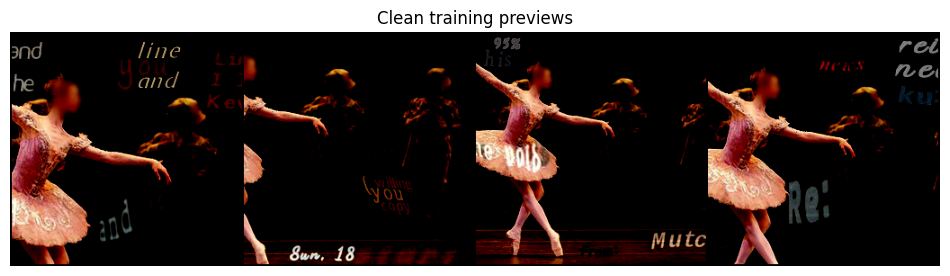

Training uses fixed paired degradations per sample for stable pix2pix supervision.


Epoch 1/10:   0%|          | 0/625 [00:00<?, ?it/s]

Saved checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_epoch_001.pt


Epoch 2/10:   0%|          | 0/625 [00:00<?, ?it/s]

Saved checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_epoch_002.pt


...

Epoch 10/10:   0%|          | 0/625 [00:00<?, ?it/s]

Saved checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_epoch_010.pt


,epoch,g,d
0,1,15.585082,0.584439
1,2,12.360615,0.578515
2,3,12.356705,0.548836
3,4,12.314303,0.551640
4,5,12.420269,0.547095
5,6,12.366224,0.532496
6,7,12.314949,0.536737
7,8,12.405108,0.527440
8,9,12.327158,0.537223
9,10,12.341909,0.527340


Evaluating OCR outputs:   0%|          | 0/200 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


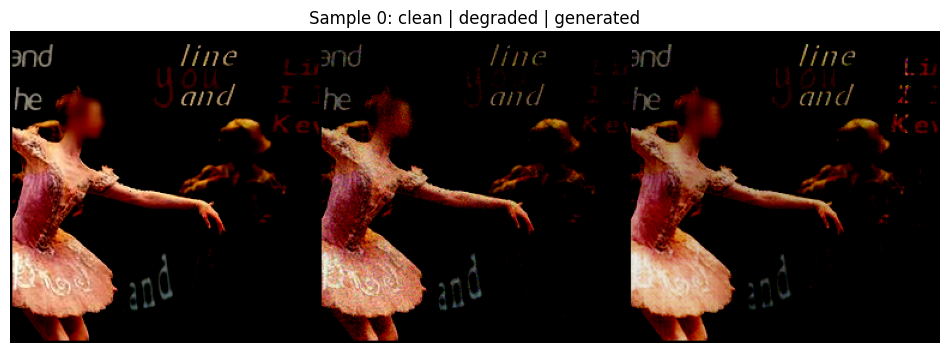

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


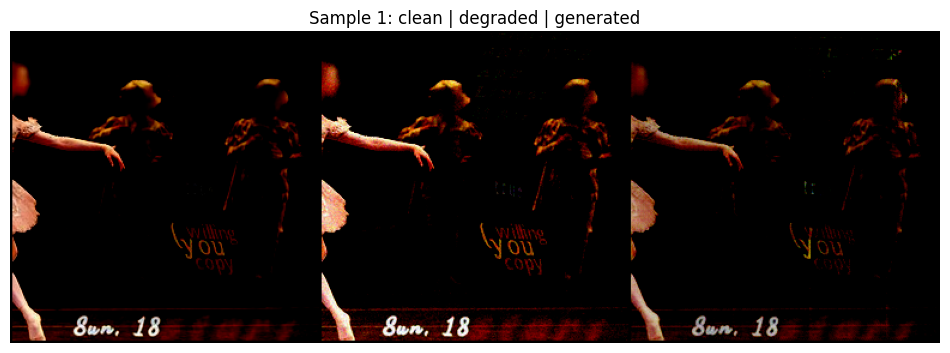

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


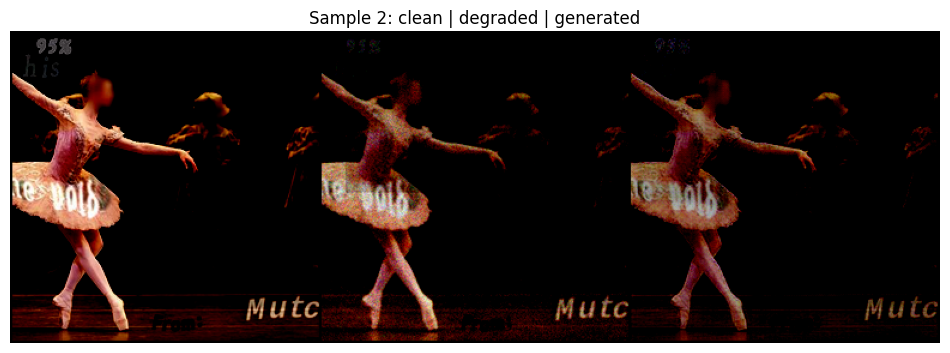

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


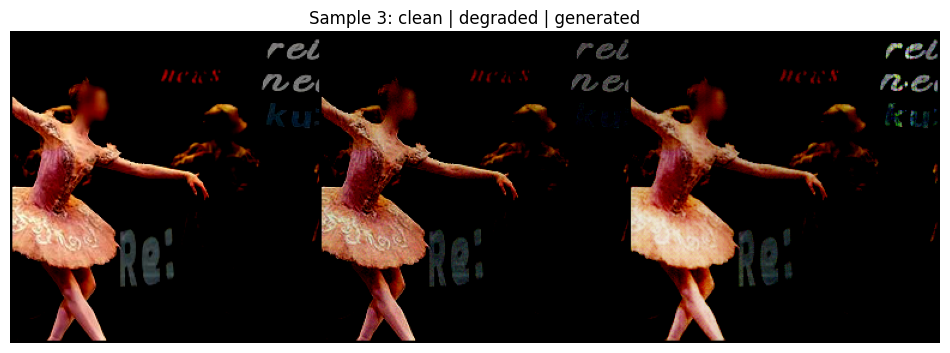

,index,engine,clean_text,clean_ocr,baseline_ocr,generated_ocr,image_path
0,0,trocr,Lines: I lost Kevin will line...,TAX,TAX,1,/kaggle/input/datasets/wassefy/synthtext/Synth...
1,0,easyocr,Lines: I lost Kevin will line...,Ind he line Li Jand I 1 Kol tL O1 Xand,"ind he line Li Jand I , Kol tl 0 Xand",ind he line Li Yand 1 2 Kol t 01 Xand,/kaggle/input/datasets/wassefy/synthtext/Synth...
2,0,tesseract,Lines: I lost Kevin will line...,Le re\nau\nSite a\n\noS 2\n\n \n,\n,pt Hg eT\n\n \n,/kaggle/input/datasets/wassefy/synthtext/Synth...
3,0,ocrspace,Lines: I lost Kevin will line...,and\nhe\nline\nY and\nLi\nKe\nOT\nKand,and\nhe\nline\n40\nand\nLi\nKe\nand,and\nhe\nline\nY and\nKand\nLi\nKe\nOT,/kaggle/input/datasets/wassefy/synthtext/Synth...
4,1,trocr,with Sender: BNR-RTP...,MA,MA,MA,/kaggle/input/datasets/wassefy/synthtext/Synth...


,index,engine,clean_text,clean_ocr,baseline_ocr,generated_ocr,image_path,baseline_cer,baseline_wer,baseline_exact_match,generated_cer,generated_wer,generated_exact_match,clean_ocr_cer,clean_ocr_wer,clean_ocr_exact_match,generated_cer_delta,generated_wer_delta,attack_success
0,0,trocr,Lines: I lost Kevin will line...,TAX,TAX,1,/kaggle/input/datasets/wassefy/synthtext/Synth...,0.970588,1.000000,False,1.000000,1.000000,False,0.970588,1.000000,False,0.029412,0.0,True
1,0,easyocr,Lines: I lost Kevin will line...,Ind he line Li Jand I 1 Kol tL O1 Xand,"ind he line Li Jand I , Kol tl 0 Xand",ind he line Li Yand 1 2 Kol t 01 Xand,/kaggle/input/datasets/wassefy/synthtext/Synth...,0.705882,0.933333,False,0.691176,0.933333,False,0.691176,0.933333,False,-0.014706,0.0,False
2,0,tesseract,Lines: I lost Kevin will line...,Le re\nau\nSite a\n\noS 2\n\n \n,\n,pt Hg eT\n\n \n,/kaggle/input/datasets/wassefy/synthtext/Synth...,1.000000,1.000000,False,0.911765,1.000000,False,0.794118,1.000000,False,-0.088235,0.0,False
3,0,ocrspace,Lines: I lost Kevin will line...,and\nhe\nline\nY and\nLi\nKe\nOT\nKand,and\nhe\nline\n40\nand\nLi\nKe\nand,and\nhe\nline\nY and\nKand\nLi\nKe\nOT,/kaggle/input/datasets/wassefy/synthtext/Synth...,0.735294,0.866667,False,0.676471,0.866667,False,0.691176,0.866667,False,-0.058824,0.0,False
4,1,trocr,with Sender: BNR-RTP...,MA,MA,MA,/kaggle/input/datasets/wassefy/synthtext/Synth...,0.972222,1.000000,False,0.972222,1.000000,False,0.972222,1.000000,False,0.000000,0.0,False


,engine,samples,clean_accuracy,baseline_accuracy,generated_accuracy,attack_success_rate,clean_cer,baseline_cer,generated_cer,clean_wer,...,generated_wer,generated_cer_delta,generated_wer_delta,clean_accuracy_pct,baseline_accuracy_pct,generated_accuracy_pct,attack_success_rate_pct,generated_vs_baseline_accuracy_delta_pct,generated_vs_baseline_cer_delta,generated_vs_baseline_wer_delta
0,ocrspace,200,0.000,0.000,0.000,0.130,0.902027,0.902872,0.906343,0.950199,...,0.951625,0.003470,0.000082,0.0,0.0,0.0,13.0,0.0,0.003470,0.000082
1,easyocr,200,0.005,0.005,0.005,0.385,0.699540,0.714141,0.716727,0.923372,...,0.931309,0.002586,0.000504,0.5,0.5,0.5,38.5,0.0,0.002586,0.000504
2,trocr,200,0.005,0.005,0.005,0.100,0.958422,0.960778,0.963219,1.000763,...,0.999224,0.002441,0.005990,0.5,0.5,0.5,10.0,0.0,0.002441,0.005990
3,tesseract,200,0.000,0.000,0.000,0.160,0.969685,0.971636,0.970890,0.992648,...,0.994616,-0.000746,-0.004836,0.0,0.0,0.0,16.0,0.0,-0.000746,-0.004836


Sanity check: clean OCR is still very weak on this setup. If this persists, increase image_size, reduce sample complexity, or switch to cropped word-level regions.


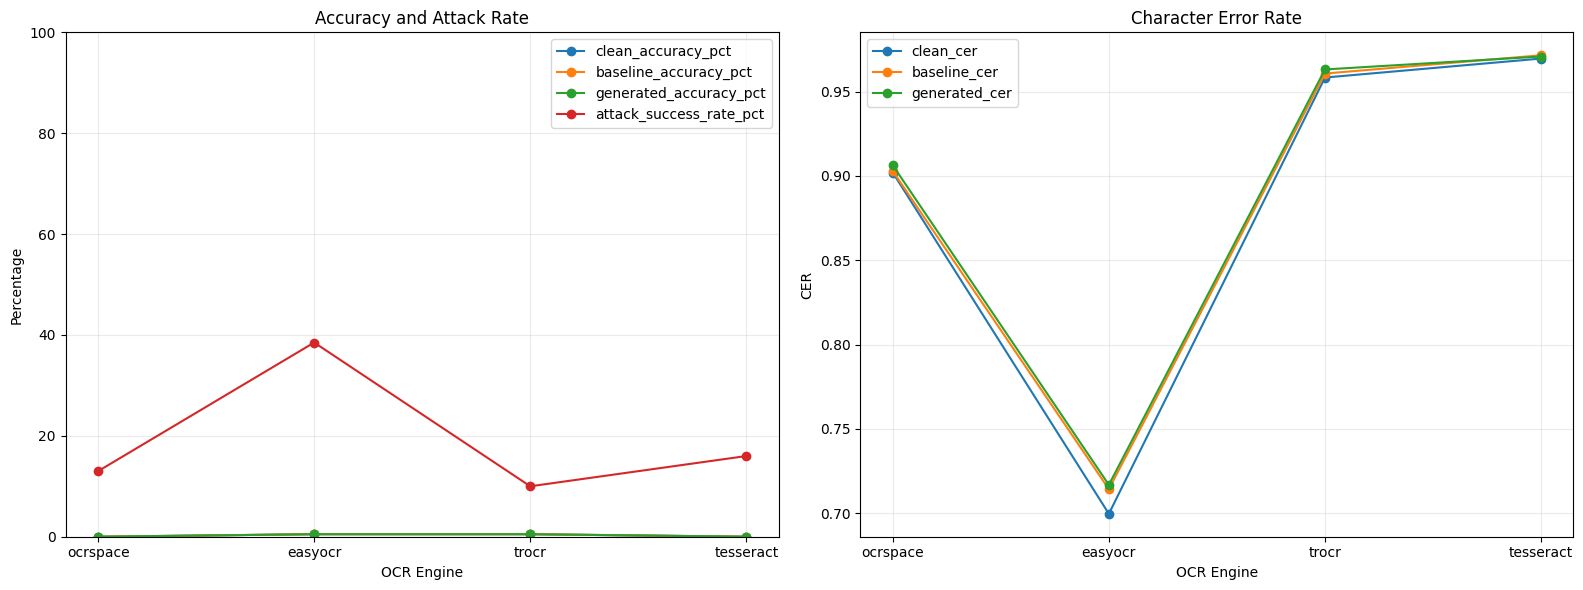

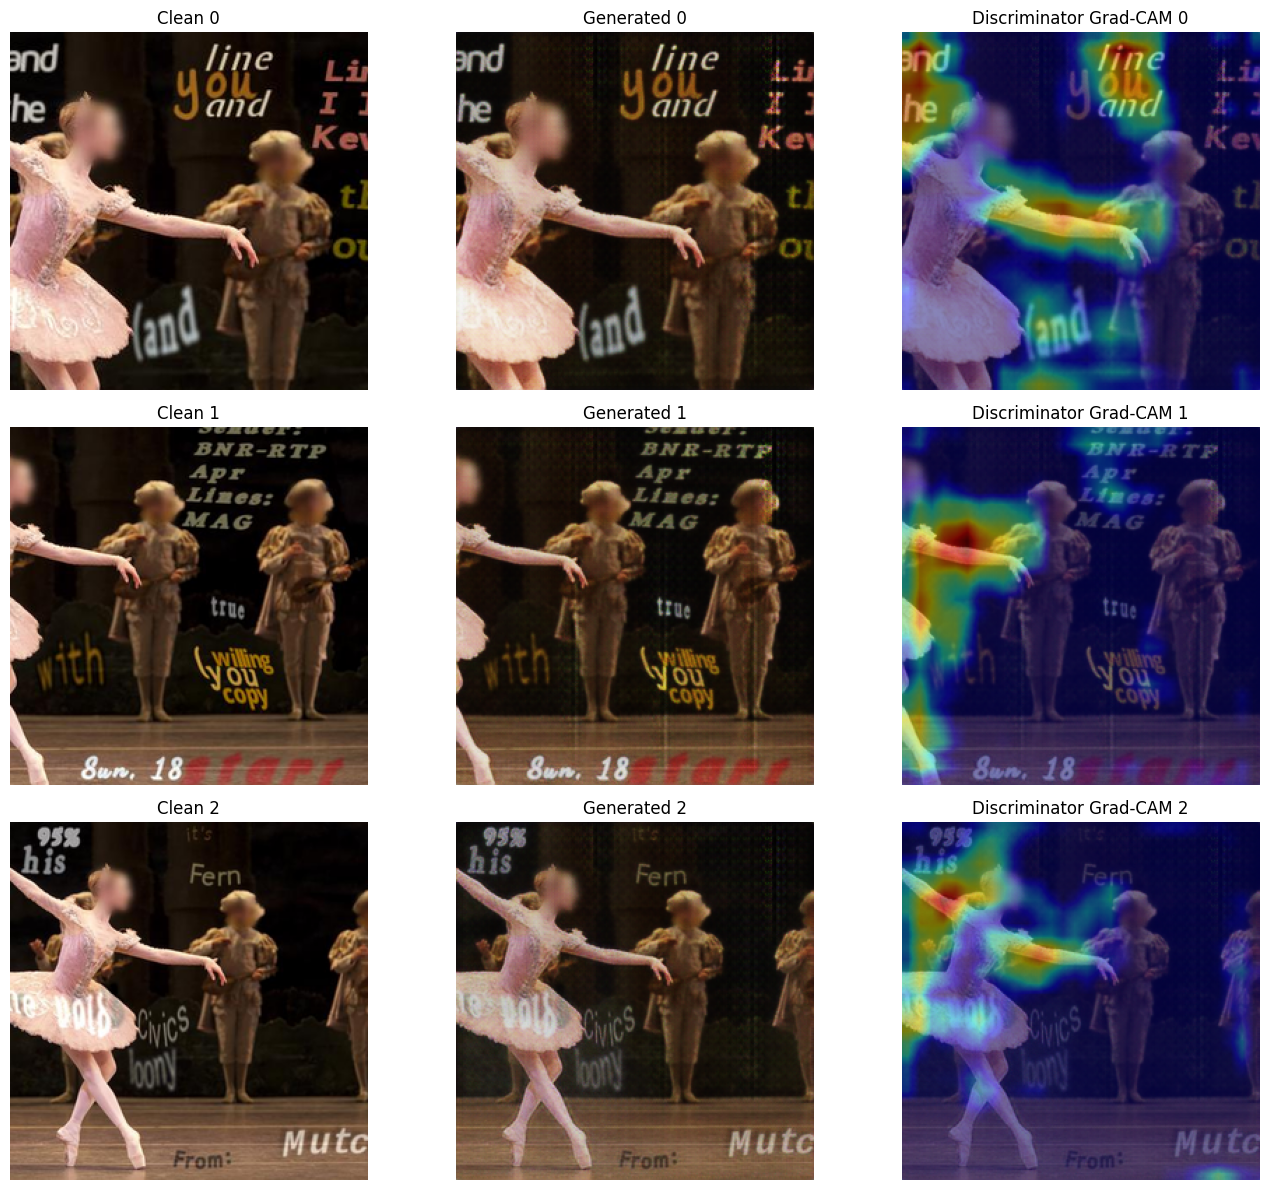

Saved OCR results to /kaggle/working/ocr_gan_outputs/ocr_gan_results.csv
Saved OCR summary to /kaggle/working/ocr_gan_outputs/ocr_gan_summary.csv
Training and evaluation helpers are ready.


In [8]:
def show_image_grid(tensor_batch: torch.Tensor, title: str = "Samples", nrow: int = 4) -> None:
    grid = make_grid(normalize_for_display(tensor_batch), nrow=nrow)
    plt.figure(figsize=(12, 8))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()


def plot_ocr_summary(summary_dataframe: pd.DataFrame) -> None:
    if summary_dataframe.empty:
        return

    _, axes = plt.subplots(1, 2, figsize=(16, 6))

    accuracy_columns = [
        "clean_accuracy_pct",
        "baseline_accuracy_pct",
        "generated_accuracy_pct",
        "attack_success_rate_pct",
    ]
    for metric_name in accuracy_columns:
        axes[0].plot(summary_dataframe["engine"], summary_dataframe[metric_name], marker="o", label=metric_name)
    axes[0].set_title("Accuracy and Attack Rate")
    axes[0].set_ylabel("Percentage")
    axes[0].set_xlabel("OCR Engine")
    axes[0].set_ylim(0, 100)
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    error_columns = ["clean_cer", "baseline_cer", "generated_cer"]
    for metric_name in error_columns:
        axes[1].plot(summary_dataframe["engine"], summary_dataframe[metric_name], marker="o", label=metric_name)
    axes[1].set_title("Character Error Rate")
    axes[1].set_ylabel("CER")
    axes[1].set_xlabel("OCR Engine")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


if len(dataset_dataframe) > 0:
    preview_dataset = PairedDocumentDataset(dataset_dataframe.head(min(8, len(dataset_dataframe))), image_size=config.image_size, training=False)
    preview_batch = [preview_dataset[index]["clean"] for index in range(min(4, len(preview_dataset)))]
    if preview_batch:
        show_image_grid(torch.stack(preview_batch), title="Clean training previews")


TRAIN_DEGRADATION_SEED = RANDOM_SEED + 1_000
EVAL_DEGRADATION_SEED = RANDOM_SEED + 2_000

train_dataset = PairedDocumentDataset(
    dataset_dataframe,
    image_size=config.image_size,
    training=True,
    deterministic_degradation=True,
    base_seed=TRAIN_DEGRADATION_SEED,
) if len(dataset_dataframe) > 0 else None
eval_dataset = PairedDocumentDataset(
    dataset_dataframe,
    image_size=config.image_size,
    training=True,
    deterministic_degradation=True,
    base_seed=EVAL_DEGRADATION_SEED,
) if len(dataset_dataframe) > 0 else None
train_loader = None
if train_dataset is not None and len(train_dataset) > 0:
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
    )
    print("Training uses fixed paired degradations per sample for stable pix2pix supervision.")


optimizer_g = torch.optim.Adam(G.parameters(), lr=config.learning_rate, betas=(config.beta1, 0.999))
optimizer_d = torch.optim.Adam(D.parameters(), lr=config.learning_rate, betas=(config.beta1, 0.999))
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
EVAL_ENGINES = ["trocr", "easyocr", "tesseract", "ocrspace"]
ATTACK_CER_MARGIN = 0.02
ATTACK_WER_MARGIN = 0.02


def total_variation_loss(image: torch.Tensor) -> torch.Tensor:
    loss_horizontal = torch.mean(torch.abs(image[:, :, :, 1:] - image[:, :, :, :-1]))
    loss_vertical = torch.mean(torch.abs(image[:, :, 1:, :] - image[:, :, :-1, :]))
    return loss_horizontal + loss_vertical


config.lambda_tv = 0.2


def train_one_epoch(epoch_index: int) -> Dict[str, float]:
    if train_loader is None:
        raise RuntimeError("No training data found. Attach a Kaggle dataset and rerun the notebook.")

    G.train()
    D.train()
    running_losses = {"g": 0.0, "d": 0.0}
    progress = tqdm(train_loader, desc=f"Epoch {epoch_index + 1}/{config.epochs}")

    for batch in progress:
        clean_image = batch["clean"].to(DEVICE, non_blocking=True)
        target_image = batch["degraded"].to(DEVICE, non_blocking=True)

        with torch.no_grad():
            fake_image_detached = G(clean_image)

        optimizer_d.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            real_prediction = D(clean_image, target_image)
            fake_prediction = D(clean_image, fake_image_detached.detach())
            loss_d = discriminator_loss(real_prediction, fake_prediction)
        scaler.scale(loss_d).backward()
        scaler.step(optimizer_d)

        optimizer_g.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            fake_image = G(clean_image)
            fake_prediction_for_g = D(clean_image, fake_image)
            identity_image = G(target_image)
            losses = generator_loss(fake_prediction_for_g, fake_image, target_image, identity_image)
            tv_loss = total_variation_loss(fake_image)
            total_generator_loss = losses["total"] + config.lambda_tv * tv_loss
        scaler.scale(total_generator_loss).backward()
        scaler.step(optimizer_g)
        scaler.update()

        running_losses["g"] += float(total_generator_loss.detach().cpu())
        running_losses["d"] += float(loss_d.detach().cpu())
        progress.set_postfix({
            "g_loss": running_losses["g"] / max(progress.n, 1),
            "d_loss": running_losses["d"] / max(progress.n, 1),
            "tv": float(tv_loss.detach().cpu()),
        })

    average_losses = {key: value / max(len(train_loader), 1) for key, value in running_losses.items()}
    return average_losses


history_rows = []
if train_loader is not None:
    for epoch_index in range(config.epochs):
        epoch_losses = train_one_epoch(epoch_index)
        history_rows.append({"epoch": epoch_index + 1, **epoch_losses})
        checkpoint_path = config.checkpoints_root / f"gan_epoch_{epoch_index + 1:03d}.pt"
        torch.save({
            "generator": G.state_dict(),
            "discriminator": D.state_dict(),
            "optimizer_g": optimizer_g.state_dict(),
            "optimizer_d": optimizer_d.state_dict(),
            "epoch": epoch_index + 1,
            "config": config.__dict__,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

history_dataframe = pd.DataFrame(history_rows)
display(history_dataframe)


@torch.no_grad()
def generate_sample_outputs(sample_count: Optional[int] = None) -> pd.DataFrame:
    if eval_dataset is None or len(eval_dataset) == 0:
        return pd.DataFrame()
    G.eval()
    records = []
    effective_sample_count = min(len(eval_dataset), sample_count or config.max_eval_samples or len(eval_dataset))
    for index in tqdm(range(effective_sample_count), desc="Evaluating OCR outputs"):
        sample = eval_dataset[index]
        clean_image = sample["clean"].unsqueeze(0).to(DEVICE)
        predicted_image = G(clean_image)[0].cpu()
        predicted_pil = tensor_to_pil(predicted_image)
        clean_pil = tensor_to_pil(sample["clean"])
        degraded_pil = tensor_to_pil(sample["degraded"])
        clean_text = sample.get("text", "")
        for engine_name in EVAL_ENGINES:
            predicted_text = run_ocr_engine(engine_name, predicted_pil)
            baseline_text = run_ocr_engine(engine_name, degraded_pil)
            clean_ocr_text = run_ocr_engine(engine_name, clean_pil)
            records.append({
                "index": index,
                "engine": engine_name,
                "clean_text": clean_text,
                "clean_ocr": clean_ocr_text,
                "baseline_ocr": baseline_text,
                "generated_ocr": predicted_text,
                "image_path": sample["path"],
            })
        if index < 4:
            comparison_grid = torch.stack([sample["clean"], sample["degraded"], predicted_image])
            show_image_grid(comparison_grid, title=f"Sample {index}: clean | degraded | generated", nrow=3)
    return pd.DataFrame(records)


sample_results = generate_sample_outputs()
display(sample_results.head())


def normalize_text(text: str) -> str:
    return " ".join(text.lower().split())


def character_error_rate(prediction: str, target: str) -> float:
    prediction = normalize_text(prediction)
    target = normalize_text(target)
    if len(target) == 0:
        return float(len(prediction) > 0)
    dynamic_table = [[0] * (len(prediction) + 1) for _ in range(len(target) + 1)]
    for row_index in range(len(target) + 1):
        dynamic_table[row_index][0] = row_index
    for column_index in range(len(prediction) + 1):
        dynamic_table[0][column_index] = column_index
    for row_index in range(1, len(target) + 1):
        for column_index in range(1, len(prediction) + 1):
            substitution_cost = 0 if target[row_index - 1] == prediction[column_index - 1] else 1
            dynamic_table[row_index][column_index] = min(
                dynamic_table[row_index - 1][column_index] + 1,
                dynamic_table[row_index][column_index - 1] + 1,
                dynamic_table[row_index - 1][column_index - 1] + substitution_cost,
            )
    return dynamic_table[-1][-1] / max(len(target), 1)


def word_error_rate(prediction: str, target: str) -> float:
    prediction_tokens = normalize_text(prediction).split()
    target_tokens = normalize_text(target).split()
    if len(target_tokens) == 0:
        return float(len(prediction_tokens) > 0)
    dynamic_table = [[0] * (len(prediction_tokens) + 1) for _ in range(len(target_tokens) + 1)]
    for row_index in range(len(target_tokens) + 1):
        dynamic_table[row_index][0] = row_index
    for column_index in range(len(prediction_tokens) + 1):
        dynamic_table[0][column_index] = column_index
    for row_index in range(1, len(target_tokens) + 1):
        for column_index in range(1, len(prediction_tokens) + 1):
            substitution_cost = 0 if target_tokens[row_index - 1] == prediction_tokens[column_index - 1] else 1
            dynamic_table[row_index][column_index] = min(
                dynamic_table[row_index - 1][column_index] + 1,
                dynamic_table[row_index][column_index - 1] + 1,
                dynamic_table[row_index - 1][column_index - 1] + substitution_cost,
            )
    return dynamic_table[-1][-1] / max(len(target_tokens), 1)


def exact_match(prediction: str, target: str) -> bool:
    return normalize_text(prediction) == normalize_text(target)


def evaluate_ocr_outputs(result_dataframe: pd.DataFrame) -> pd.DataFrame:
    if result_dataframe.empty:
        return result_dataframe
    evaluation_rows = []
    for _, row in result_dataframe.iterrows():
        clean_text = row["clean_text"]
        clean_exact = exact_match(row["clean_ocr"], clean_text)
        baseline_exact = exact_match(row["baseline_ocr"], clean_text)
        generated_exact = exact_match(row["generated_ocr"], clean_text)
        clean_cer = character_error_rate(row["clean_ocr"], clean_text)
        baseline_cer = character_error_rate(row["baseline_ocr"], clean_text)
        generated_cer = character_error_rate(row["generated_ocr"], clean_text)
        clean_wer = word_error_rate(row["clean_ocr"], clean_text)
        baseline_wer = word_error_rate(row["baseline_ocr"], clean_text)
        generated_wer = word_error_rate(row["generated_ocr"], clean_text)
        evaluation_rows.append({
            **row.to_dict(),
            "baseline_cer": baseline_cer,
            "baseline_wer": baseline_wer,
            "baseline_exact_match": baseline_exact,
            "generated_cer": generated_cer,
            "generated_wer": generated_wer,
            "generated_exact_match": generated_exact,
            "clean_ocr_cer": clean_cer,
            "clean_ocr_wer": clean_wer,
            "clean_ocr_exact_match": clean_exact,
            "generated_cer_delta": generated_cer - baseline_cer,
            "generated_wer_delta": generated_wer - baseline_wer,
            "attack_success": bool(
                (generated_cer > baseline_cer + ATTACK_CER_MARGIN)
                or (generated_wer > baseline_wer + ATTACK_WER_MARGIN)
                or (baseline_exact and not generated_exact)
            ),
        })
    return pd.DataFrame(evaluation_rows)


def summarize_ocr_metrics(evaluation_dataframe: pd.DataFrame) -> pd.DataFrame:
    if evaluation_dataframe.empty:
        return evaluation_dataframe

    summary_dataframe = (
        evaluation_dataframe.groupby("engine", dropna=False)
        .agg(
            samples=("index", "count"),
            clean_accuracy=("clean_ocr_exact_match", "mean"),
            baseline_accuracy=("baseline_exact_match", "mean"),
            generated_accuracy=("generated_exact_match", "mean"),
            attack_success_rate=("attack_success", "mean"),
            clean_cer=("clean_ocr_cer", "mean"),
            baseline_cer=("baseline_cer", "mean"),
            generated_cer=("generated_cer", "mean"),
            clean_wer=("clean_ocr_wer", "mean"),
            baseline_wer=("baseline_wer", "mean"),
            generated_wer=("generated_wer", "mean"),
            generated_cer_delta=("generated_cer_delta", "mean"),
            generated_wer_delta=("generated_wer_delta", "mean"),
        )
        .reset_index()
    )

    for column in [
        "clean_accuracy",
        "baseline_accuracy",
        "generated_accuracy",
        "attack_success_rate",
        "clean_cer",
        "baseline_cer",
        "generated_cer",
        "clean_wer",
        "baseline_wer",
        "generated_wer",
        "generated_cer_delta",
        "generated_wer_delta",
    ]:
        summary_dataframe[column] = summary_dataframe[column].astype(float)

    summary_dataframe["clean_accuracy_pct"] = summary_dataframe["clean_accuracy"] * 100.0
    summary_dataframe["baseline_accuracy_pct"] = summary_dataframe["baseline_accuracy"] * 100.0
    summary_dataframe["generated_accuracy_pct"] = summary_dataframe["generated_accuracy"] * 100.0
    summary_dataframe["attack_success_rate_pct"] = summary_dataframe["attack_success_rate"] * 100.0
    summary_dataframe["generated_vs_baseline_accuracy_delta_pct"] = (
        summary_dataframe["generated_accuracy_pct"] - summary_dataframe["baseline_accuracy_pct"]
    )
    summary_dataframe["generated_vs_baseline_cer_delta"] = (
        summary_dataframe["generated_cer"] - summary_dataframe["baseline_cer"]
    )
    summary_dataframe["generated_vs_baseline_wer_delta"] = (
        summary_dataframe["generated_wer"] - summary_dataframe["baseline_wer"]
    )

    return summary_dataframe.sort_values("generated_cer_delta", ascending=False).reset_index(drop=True)


def print_ocr_sanity_checks(summary_dataframe: pd.DataFrame) -> None:
    if summary_dataframe.empty:
        return

    low_clean_accuracy = bool((summary_dataframe["clean_accuracy_pct"] <= 1.0).all())
    high_clean_cer = bool((summary_dataframe["clean_cer"] >= 0.6).all())
    if low_clean_accuracy and high_clean_cer:
        print(
            "Sanity check: clean OCR is still very weak on this setup. "
            "If this persists, increase image_size, reduce sample complexity, or switch to cropped word-level regions."
        )


def compute_discriminator_gradcam(clean_tensor: torch.Tensor, target_tensor: torch.Tensor) -> Optional[np.ndarray]:
    target_module = None
    for module in reversed(list(D.model)):
        if isinstance(module, nn.Conv2d):
            target_module = module
            break

    if target_module is None:
        return None

    activations = []
    gradients = []

    def forward_hook(*hook_args):
        activations.append(hook_args[2])

    def backward_hook(*hook_args):
        gradients.append(hook_args[2][0])

    forward_handle = target_module.register_forward_hook(forward_hook)
    backward_handle = target_module.register_full_backward_hook(backward_hook)

    try:
        D.eval()
        D.zero_grad(set_to_none=True)
        prediction = D(clean_tensor, target_tensor)
        score = prediction.mean()
        score.backward()

        if not activations or not gradients:
            return None

        activation_map = activations[0]
        gradient_map = gradients[0]
        weights = gradient_map.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * activation_map).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=clean_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam
    finally:
        forward_handle.remove()
        backward_handle.remove()
        D.zero_grad(set_to_none=True)


def visualize_discriminator_gradcam(sample_count: int = 3) -> None:
    if eval_dataset is None or len(eval_dataset) == 0 or sample_count <= 0:
        print("No data available for Grad-CAM visualization.")
        return

    _, axes = plt.subplots(sample_count, 3, figsize=(14, 4 * sample_count))
    if sample_count == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index in range(sample_count):
        sample = eval_dataset[row_index]
        clean_tensor = sample["clean"].unsqueeze(0).to(DEVICE)
        generated_tensor = G(clean_tensor).detach()
        cam = compute_discriminator_gradcam(clean_tensor, generated_tensor)

        clean_image = tensor_to_pil(sample["clean"])
        generated_image = tensor_to_pil(generated_tensor[0].cpu())

        axes[row_index, 0].imshow(clean_image)
        axes[row_index, 0].set_title(f"Clean {row_index}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(generated_image)
        axes[row_index, 1].set_title(f"Generated {row_index}")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].imshow(generated_image)
        if cam is not None:
            axes[row_index, 2].imshow(cam, cmap="jet", alpha=0.45)
        axes[row_index, 2].set_title(f"Discriminator Grad-CAM {row_index}")
        axes[row_index, 2].axis("off")

    plt.tight_layout()
    plt.show()


sample_evaluation = evaluate_ocr_outputs(sample_results)
display(sample_evaluation.head())


ocr_summary = summarize_ocr_metrics(sample_evaluation)
if not ocr_summary.empty:
    display(ocr_summary)
    print_ocr_sanity_checks(ocr_summary)
    plot_ocr_summary(ocr_summary)
else:
    print("OCR summary is empty. This usually means no samples or no OCR outputs were produced.")


visualize_discriminator_gradcam(sample_count=min(config.gradcam_samples, len(eval_dataset) if eval_dataset is not None else 0))


results_csv_path = config.output_root / "ocr_gan_results.csv"
if not sample_evaluation.empty:
    sample_evaluation.to_csv(results_csv_path, index=False)
    print(f"Saved OCR results to {results_csv_path}")


summary_csv_path = config.output_root / "ocr_gan_summary.csv"
if not ocr_summary.empty:
    ocr_summary.to_csv(summary_csv_path, index=False)
    print(f"Saved OCR summary to {summary_csv_path}")


summary_path = config.output_root / "training_summary.json"
with open(summary_path, "w", encoding="utf-8") as summary_file:
    json.dump({
        "history": history_rows,
        "num_samples": int(len(dataset_dataframe)),
        "evaluated_samples": int(0 if sample_results.empty else sample_results["index"].nunique()),
        "device": str(DEVICE),
        "eval_engines": EVAL_ENGINES,
        "attack_thresholds": {
            "cer_margin": ATTACK_CER_MARGIN,
            "wer_margin": ATTACK_WER_MARGIN,
        },
        "train_degradation_seed": TRAIN_DEGRADATION_SEED,
        "eval_degradation_seed": EVAL_DEGRADATION_SEED,
        "ocr_summary": [] if ocr_summary.empty else ocr_summary.to_dict(orient="records"),
    }, summary_file, indent=2)

print("Training and evaluation helpers are ready.")